In [12]:
import sys
!{sys.executable} -m pip install --user tensorflow opencv-python matplotlib scikit-learn

In [16]:
import tensorflow as tf
import numpy as np
import cv2
import os
import random
import pathlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [18]:
base_path = r"C:\Users\kulka\OneDrive\Desktop\Advanced ML lab\Experiment8\video_dataset"

os.makedirs(base_path, exist_ok=True)

classes = ["circle", "square"]
for c in classes:
    os.makedirs(os.path.join(base_path, c), exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [19]:
IMG_SIZE = 64
FRAMES = 16
VIDEOS_PER_CLASS = 40

fourcc = cv2.VideoWriter_fourcc(*'XVID')

for cls in classes:
    
    for v in range(VIDEOS_PER_CLASS):
        
        path = os.path.join(base_path, cls, f"{cls}_{v}.avi")
        out = cv2.VideoWriter(path, fourcc, 5, (IMG_SIZE, IMG_SIZE))
        
        for i in range(FRAMES):
            
            frame = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            
            x = np.random.randint(15, 45)
            y = np.random.randint(15, 45)
            
            if cls == "circle":
                cv2.circle(frame, (x,y), 10, (255,255,255), -1)
            else:
                cv2.rectangle(frame, (x,y), (x+15,y+15), (255,255,255), -1)
            
            out.write(frame)
        
        out.release()

print("Videos Created Successfully")

Videos Created Successfully


In [20]:
X = []
y = []

for label, cls in enumerate(classes):
    
    folder = os.path.join(base_path, cls)
    
    for file in os.listdir(folder):
        
        video_path = os.path.join(folder, file)
        cap = cv2.VideoCapture(video_path)
        
        frames = []
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame = cv2.resize(frame, (64,64))
            frame = frame / 255.0
            frames.append(frame)
        
        cap.release()
        
        if len(frames) == 16:
            X.append(frames)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (80, 16, 64, 64, 3)
Y Shape: (80,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(64, 16, 64, 64, 3)
(16, 16, 64, 64, 3)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, LSTM
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(TimeDistributed(
    Conv2D(32,(3,3),activation='relu'),
    input_shape=(16,64,64,3)
))

model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(
    Conv2D(64,(3,3),activation='relu')
))

model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))

model.add(Dense(32, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\kulka\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 16, 62, 62, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 31, 31, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 29, 29, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 16, 14, 14, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 16, 12544)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     3,227,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,249,442 (12.40 MB)

 Trainable params: 3,249,442 (12.40 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=4,
    validation_data=(X_test, y_test)
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 792ms/step - accuracy: 0.9062 - loss: 0.1938 - val_accuracy: 0.9375 - val_loss: 0.0761
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 765ms/step - accuracy: 0.9688 - loss: 0.0815 - val_accuracy: 1.0000 - val_loss: 0.0081
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 668ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 0.0087
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 697ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 680ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 762ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 760ms/step - accuracy: 1.0000 - loss: 7.4380e-04 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 671ms/step - accuracy: 1.0000 - loss: 5.4865e-04 - 

In [24]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy =", acc*100)
print("Loss =", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 4.4292e-04
Accuracy = 100.0
Loss = 0.00044292211532592773


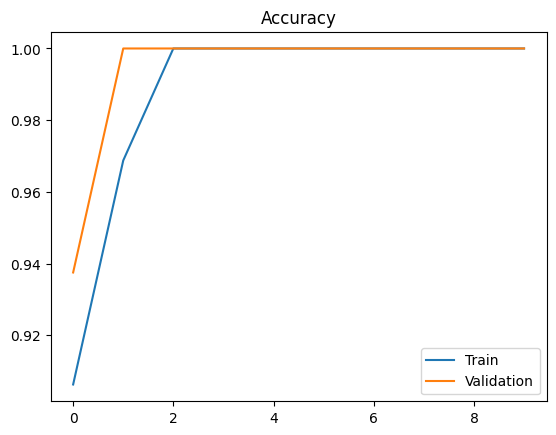

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

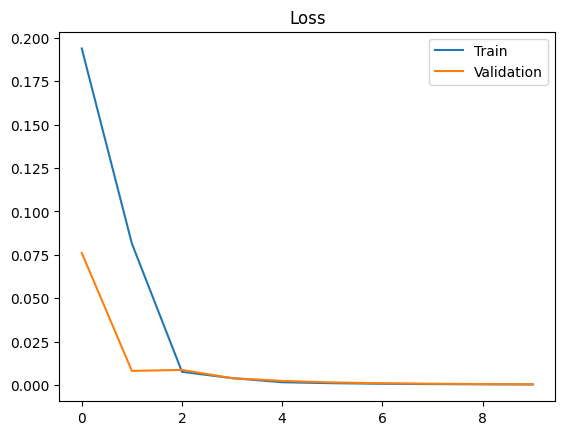

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [27]:
pred = model.predict(X_test)
pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         5

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16

